# 08 Velocity Observer Bake Off

The servo has to know how fast its shaft is turning, and it has four ways to guess. It can
difference the potentiometer. It can rearrange the motor's electrical equation and work the
speed out from voltage and current. It can let the bridge float for a moment and read the
back-EMF straight off the terminals. Or it can count the commutation ripple in the current,
which is the most accurate of the lot and also the one the chip cannot afford.

Notebook 07 measured how noisy every channel is. This one spends that measurement. I score
each candidate against a speed reference that does not touch the pot at all, and then I work
out the blending weights from the measured noise instead of turning knobs until the plot
looks calm.

If you are short on time, here is where it lands:

- The model based back-EMF estimate wins. A single unfiltered sample of it is already twice as
  quiet as a pot derivative taken over a 20 ms window, and averaging it over 1 ms makes it nine
  times quieter, with a twentieth of the lag.
- The six percent bias that estimate carried was two bookkeeping mistakes, not physics. Both
  are fixed here and it lands within 1.4% of the reference, with about 1% of scatter.
- The measured covariances say the pot deserves under one part in a thousand of the velocity
  weight, and the firmware currently gives it all of it. That is the story behind
  $\hat\omega$ railing at rest.
- One number notebook 07 published needs a correction. The pot's noise is not white, so
  differentiating it is seven times gentler than the white noise arithmetic predicts. The pot
  still loses.

## Picking a rig

Everything below reads one dataset, and the dataset's manifest names the board and the servo
it came off. So the shunt value, the divider ratio and the gear ratio all travel with the
captures rather than living in my head.

Two tables print. The first is what the hardware is. The second is what somebody measured
when they looked, with a bracket and a source on every entry.

2S is the primary supply for every number here. USB droops under load, so a fit against duty
on USB quietly folds rail droop into the duty axis.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch, detrend, butter, filtfilt, hilbert

import oscnb

ds = oscnb.use("sg90-a__dev-v006-D__2s")
board, servo = oscnb.current().board, oscnb.current().servo

FS = board.tick_hz                                    # 20 kHz, one telemetry sample per tick
DT = 1.0 / FS
GEAR = servo.measured["gear_ratio_measured"].value    # 234.73:1, counted teeth, exact
KE = servo.measured["ke_measured"].value / 1e3        # V per motor rev/s, from the registry
PPR = servo.measured["ripple_order_measured"].value   # 6 current spikes per motor revolution

dataset  sg90-a__dev-v006-D__2s
supply   2s
rig      SG90 clone, unit A on osc-dev-v006 board D (bodged toward rev-2A)



,captures,recordings per capture,names
experiment,,,
breakaway,5,1,sweep
bridge,5,3,"fast, slow, spindown"
grid,10,1,sweep
reversal,5,1,sweep
ripple,5,1,sweep
stepcoast,5,5,"step120, step20, step40, step60, step80"



derived constants (what the hardware is)


value
where            quantity                                           unit                         
board            converter step                                     mV per count           0.8057
                 terminal divider ratio r                                                  3.0606
                 terminal difference                                mV per count           2.4658
                 terminal bias VB                                   mV                   627.9352
                                                                    counts               779.4008
                 driven-low terminal reads                          counts               524.7451
                 motor current                                      mA per count           0.8952
                                                                    counts per A        1117.0909
                 shunt                                              mOhm                  60.0000
                 amplifier gain                                     x                     15.0000
                 rail tap ratio                                                            2.5000
                 sample rate                                        samples per ms        20.0000
                 current settled from (UNVERIFIED)                  % duty                13.3333
                 voltage settled from (UNVERIFIED)                  % duty                13.3333
servo            pot intercept                                      counts               232.0000
                 pot slope                                          counts per degree     19.9600
                 envelope low                                       counts (10 deg)      431.6000
                 envelope high                                      counts (170 deg)    3625.2000
                 runway                                             counts              3193.6000
                 seek guard low                                     counts               432.0000
                 seek guard high                                    counts              3625.0000
servo (measured) gear_ratio_measured [234.73, 234.73] mechanical... :1                   234.7300
                 ripple_order_measured [6, 6] bringup isns-diff ... per motor rev          6.0000
                 kv_measured [7880, 8040] bringup isns-diff run28   RPM/V               7960.0000
                 kt_measured [1.19, 1.21] bringup isns-diff run28   mN-m/A                 1.2000
                 r_motor_measured [4.16, 4.24] bringup isns-diff... Ohm                    4.2000
                 l_motor_measured [0.45, 0.55] bringup isns-diff... mH                     0.5000
                 stall_current_measured [1.45, 1.55] bringup isn... A                      1.5000
                 stall_torque_measured [1.75, 1.85] bringup isns... mN-m                   1.8000
                 free_run_current_measured [0.078, 0.084] bringu... A                      0.0810
                 r_winding_measured [4.3, 4.8] nb03, full duty o... Ohm                    4.5000
                 pot_scale_measured [18.07, 18.49] ripple tach v... counts/deg            18.2900
                 coast_bemf_slope_measured [0.19, 0.204] nb01, c... V per wiper V/s        0.1970
                 ke_measured [7.29, 7.49] ripple speed + coast B... mV per motor rev/s     7.3670


measured values (what someone found when they looked)


value                 unit           bracket  \
where quantity                                                            
board vb_bias            781.000               counts        [775, 783]   
      rail_droop_usb      -3.500  % over 20-100% duty          [-4, -3]   
      opa_noise_floor      2.200           counts RMS          [2, 2.4]   
      esd_clamp_skew       1.800               V bemf        [1.7, 1.9]   
servo gear_ratio         234.730                   :1  [234.73, 234.73]   
      ripple_order         6.000        per motor rev            [6, 6]   
      kv                7960.000                RPM/V      [7880, 8040]   
      kt                   1.200               mN-m/A      [1.19, 1.21]   
      r_motor              4.200                  Ohm      [4.16, 4.24]   
      l_motor              0.500                   mH      [0.45, 0.55]   
      stall_current        1.500                    A      [1.45, 1.55]   
      stall_torque         1.800                 mN-m      [1.75, 1.85]   
      free_run_current     0.081                    A    [0.078, 0.084]   
      r_winding            4.500                  Ohm        [4.3, 4.8]   
      pot_scale           18.290           counts/deg    [18.07, 18.49]   
      coast_bemf_slope     0.197      V per wiper V/s     [0.19, 0.204]   
      ke                   7.367   mV per motor rev/s      [7.29, 7.49]   

                                                                   source  \
where quantity                                                              
board vb_bias                     Hi-Z rest baseline, 2S grid + stepcoast   
      rail_droop_usb                      2S vs USB grid, 5 captures each   
      opa_noise_floor                             bringup isns-diff run29   
      esd_clamp_skew                           bringup isns-diff findings   
servo gear_ratio                          mechanical/sg90/measurements.py   
      ripple_order                           bringup isns-diff runs 25-27   
      kv                                          bringup isns-diff run28   
      kt                                          bringup isns-diff run28   
      r_motor                                     bringup isns-diff run28   
      l_motor                                     bringup isns-diff run28   
      stall_current                               bringup isns-diff run28   
      stall_torque                                bringup isns-diff run28   
      free_run_current                            bringup isns-diff run28   
      r_winding                              nb03, full duty onset anchor   
      pot_scale         ripple tach vs counted gear ratio, 2S grid 30-...   
      coast_bemf_slope                                      nb01, chain 2   
      ke                ripple speed + coast BEMF, 2S bridge spindown,...   

                                                                   caveat  
where quantity                                                             
board vb_bias           nominal 779 from the 200/47 network, so 0.3%. ...  
      rail_droop_usb    USB also dips -21.8% transiently at 0.76 A; 2S...  
      opa_noise_floor   arm-B external network at G15; the internal PG...  
      esd_clamp_skew    above this the A-side ESD clamp skews the divi...  
servo gear_ratio        (47*38*32*23)/(10*10*8*7), counted teeth on th...  
      ripple_order      3-segment commutator x 2 brushes; optical tach...  
      kv                bare can, +/-1% HSI scale; pinion stayed on th...  
      kt                                                                   
      r_motor           bare can. nb03 got 4.5 [4.3, 4.8] in-servo via...  
      l_motor                            locked-rotor burst, tau_e 102 us  
      stall_current                                       = V/R confirmed  
      stall_torque                                                         
      free_run_current                                         at duty 65

## What counts as truth

I need a speed reference that is better than everything I am scoring, and it cannot be the
pot. Notebook 06 showed the pot's local gain swinging by a factor of 3.7 across the travel,
and the Ke closure showed that using pot speed as the reference throws the answer off by 13
to 28 percent with a spread of 26 percent. Against the ripple line the same measurement has
a spread of 1.9 percent. So the pot is a thing being scored, never the scorer.

The reference is the commutation ripple. A brushed can with three segments and two brushes
puts six current spikes into the shunt per motor revolution, so the frequency of that line
divided by six is the motor speed. Two rules from notebook 06 and the ripple work, both of
which I follow here and neither of which I re-derive.

1. Search only 1400 to 5200 Hz. A bare peak search starting at DC locks onto a subharmonic
   and hands back a clean looking answer that is an integer fraction of the truth.
2. Stay between 30 and 45 percent duty. Below that the line falls out of the search band.
   Above about 50 percent a three per revolution subharmonic takes over.

I use the line two ways. Averaged over a whole rung it gives one very solid number. Band
passed and run through a Hilbert transform it gives speed as a function of time inside the
rung, which is what lets me score an estimator sample by sample instead of rung by rung.

In [2]:
def line_hz(x, lo=1400.0, hi=5200.0, nperseg=4096):
    """
    Frequency of the commutation line. Welch spectrum, peak inside the allowed band only,
    then a parabolic fit through the peak bin and its two neighbours so the answer is not
    quantised to the bin spacing (4.9 Hz at nperseg 4096, which is 0.2% at 2 kHz).
    """
    x = detrend(np.asarray(x, float))
    f, P = welch(x, fs=FS, nperseg=min(nperseg, len(x)))
    m = (f > lo) & (f < hi)
    fm, Pm = f[m], P[m]
    i = int(np.argmax(Pm))
    if 0 < i < len(fm) - 1:                       # log-parabola vertex, standard peak interp
        a, b, c = np.log(Pm[i - 1]), np.log(Pm[i]), np.log(Pm[i + 1])
        return fm[i] + 0.5 * (a - c) / (a - 2 * b + c) * (fm[1] - fm[0])
    return fm[i]


def ripple_speed(x, f0=None, bw=0.30, smooth=200):
    """
    Motor speed in revolutions per second, sample by sample.

    Band pass the current around the line, take the analytic signal, unwrap its phase, and
    differentiate. Phase accumulates at 2*pi*f per second and there are PPR cycles per motor
    revolution, so the derivative divided by 2*pi*PPR is revolutions per second. The 10 ms
    smoothing window is what keeps the phase derivative from being dominated by the noise
    riding on the line itself.
    """
    x = detrend(np.asarray(x, float))
    f0 = f0 if f0 is not None else line_hz(x)
    b, a = butter(3, [f0 * (1 - bw) / (FS / 2), f0 * (1 + bw) / (FS / 2)], btype="band")
    ph = np.unwrap(np.angle(hilbert(filtfilt(b, a, x))))
    w = smooth
    out = np.full(len(ph), np.nan)
    out[w // 2:len(ph) - w + w // 2] = (ph[w:] - ph[:-w]) / (w * DT) / (2 * np.pi * PPR)
    return out


def rungs(dataset, experiment="grid", duties=(30, 35, 40, 45), recording="sweep"):
    """Every drive segment at one of the listed duties, both directions, all captures."""
    for cap in dataset.captures(experiment):
        df = dataset.read(experiment, cap, recording)
        # every capture opens with a one second zero-duty baseline. That is the current
        # channel's own bias reading, and it belongs to this capture, not to the board.
        bias = df[df.cmd_duty_q15 == 0].current_raw.mean()
        for seg, g in df.groupby("seg"):
            duty = round(abs(int(g.cmd_duty_q15.iloc[0])) / 32767 * 100)
            if duties is not None and duty not in duties:
                continue
            yield cap, duty, bias, g.sort_values("tick")

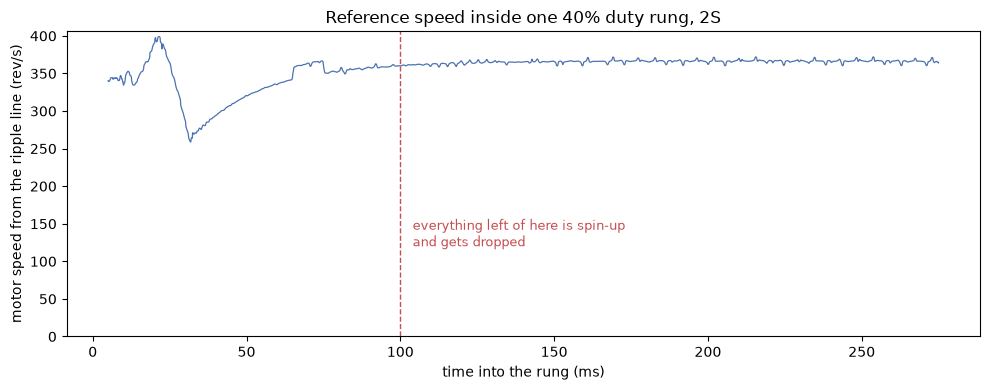

In [3]:
# One rung, start to finish, with the ripple reference tracking through it.
g = next(g for cap, d, b, g in rungs(ds, duties=(40,)) if int(g.dir.iloc[0]) == 1)
sp = ripple_speed(g.current_raw.values)
t = g.tick.values * DT * 1e3

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t, sp, lw=0.9, color="#4c72b0")
ax.axvline(100, color="#c44e52", ls="--", lw=1)
ax.text(104, 120, "everything left of here is spin-up\nand gets dropped", fontsize=9, color="#c44e52")
ax.set_xlabel("time into the rung (ms)")
ax.set_ylabel("motor speed from the ripple line (rev/s)")
ax.set_title("Reference speed inside one 40% duty rung, 2S")
ax.set_ylim(0, None)
plt.tight_layout(); plt.show()

**What you are looking at:** the motor's speed through a single rung, measured from the
commutation ripple and nothing else. The shaft takes about 80 ms to get up to speed and then
holds flat for the remaining 180 ms.

That spin-up is the first thing that has to be dealt with, and it caused one of the two
errors I found. A rung average taken over the whole window is not an average of the steady
speed, and more importantly the current during spin-up is much larger than the settled
current. At 40 percent duty the whole-rung mean current is 0.142 A while the settled mean is
0.092 A. Averaging one against the other pairs a nearly settled speed with a badly inflated
current. From here on every rung drops its first 100 ms.

## The candidates

All four estimate the same thing, the motor shaft speed $\omega_m$ in revolutions per second.

**(a) and (b), the pot derivative.** Difference the position channel over a window of $W$
ticks and scale.

$$\hat\omega_\text{pot} = \frac{\theta[k] - \theta[k-W]}{W\,T_s}\cdot\frac{N}{C}$$

$C$ is the pot's counts per output revolution and $N$ is the gear ratio. The raw version is
$W = 1$. The widened version is whatever $W$ turns out to be worth, which is the question.

**(c) the model back-EMF.** Rearrange the motor's electrical equation. Averaged over a PWM
period the inductive term drops out, so

$$\hat\omega_\text{bemf} = \frac{\bar v - R\,\bar i}{K_e}$$

$\bar v$ and $\bar i$ are the period averages of terminal voltage and winding current. Both of
those bars hide a trap, and the traps are what the next two sections are about.

**(d) the direct back-EMF.** Let the bridge float. With no current there is no $R\,i$ term
at all and the terminals read $K_e\,\omega_m$ directly.

**(e) a fusion of (b) and (c)**, weighted by the noise notebook 07 measured.

$K_e$ comes from the servo registry, where it was measured by ripple speed against coast
back-EMF. $R$ I measure from these captures, next.

## Winding resistance, from the data itself

The model back-EMF needs $R$, and $R$ moves with temperature. Copper gains 0.393% per degree,
so a motor 40 degrees into a warm up is a motor whose resistance grew 16 percent.

There is no need for a separate experiment. At the instant a rung starts the shaft is
stationary, so the back-EMF term is exactly zero and the winding is a plain resistor. Wait for
the current to settle, then read $R = \bar v / \bar i$ before the shaft has moved.

This doubles as the test of the whole $\bar v$ and $\bar i$ story, because it runs at every
duty. If $\bar v = d\cdot v_\text{crest}$ and $\bar i = i_\text{crest}$ are both right, one
resistance should come out at every duty from 30 percent to 100.

shaft travel inside the measurement window: 3.7 counts, against a pot noise of about 8, so the shaft really has not moved

     v_mean        i_mean             R       
       mean    std   mean    std   mean    std
duty                                          
30    2.227  0.011  0.613  0.014  3.643  0.088
40    2.938  0.015  0.782  0.011  3.761  0.056
50    3.632  0.020  0.943  0.009  3.856  0.040
60    4.312  0.023  1.098  0.014  3.931  0.040
70    4.975  0.027  1.251  0.015  3.981  0.032
80    5.624  0.031  1.403  0.027  4.012  0.064
90    6.250  0.036  1.568  0.038  3.998  0.079
100   6.862  0.050  1.726  0.041  3.985  0.085

anchor, mean over 70 to 100% duty:  3.994 ohm  (spread inside that range 0.014)
across the full 30 to 100% ladder:  [3.64, 4.01] ohm


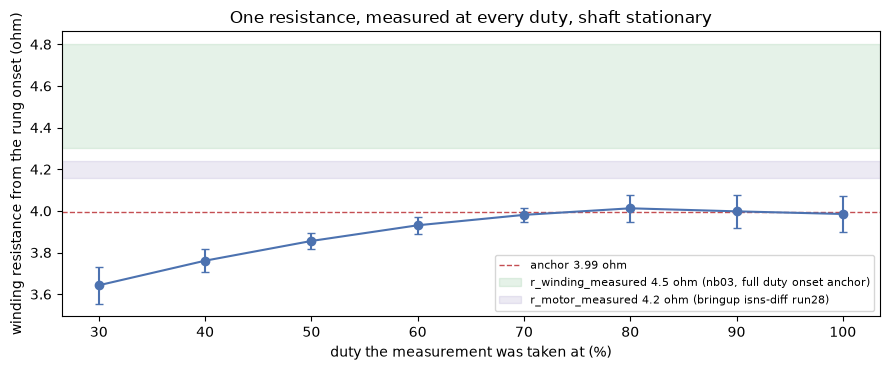

In [4]:
rows = []
for cap, duty, bias, g in rungs(ds, duties=(30, 40, 50, 60, 70, 80, 90, 100)):
    # ticks 15..35 = 0.75 to 1.75 ms in. The current needs about 10 ticks to settle after the
    # bridge turns on, and the shaft has barely moved by 1.75 ms, so the back-EMF term is
    # still negligible. The first two samples carry the previous segment's duty and go.
    w = g.iloc[15:36]
    v = np.abs(board.diff_v(w.vmotor_a.values, w.vmotor_b.values))
    i = (w.current_raw.values - bias) * board.a_per_count
    d = np.abs(w.duty_q15.values).mean() / 32767
    rows.append(dict(capture=cap, duty=duty, dir=int(g.dir.iloc[0]),
                     v_mean=(d * v).mean(), i_mean=i.mean(), R=(d * v / i).mean(),
                     travel=abs(float(w.pos.iloc[-1]) - float(w.pos.iloc[0]))))
Ron = pd.DataFrame(rows)
print(f"shaft travel inside the measurement window: {Ron.travel.mean():.1f} counts, against a "
      f"pot noise of about 8, so the shaft really has not moved\n")
print(Ron.groupby("duty")[["v_mean", "i_mean", "R"]].agg(["mean", "std"]).round(3).to_string())

# 70% duty and up is where the answer stops moving, so that is the anchor. The lower duties
# are not thrown away, they are the open question at the bottom of this notebook.
R_WIND = Ron[Ron.duty >= 70].R.mean()
R_LO, R_HI = Ron.groupby("duty").R.mean().min(), Ron.groupby("duty").R.mean().max()
print(f"\nanchor, mean over 70 to 100% duty:  {R_WIND:.3f} ohm  "
      f"(spread inside that range {Ron[Ron.duty>=70].groupby('duty').R.mean().std():.3f})")
print(f"across the full 30 to 100% ladder:  [{R_LO:.2f}, {R_HI:.2f}] ohm")

fig, ax = plt.subplots(figsize=(9, 3.8))
m = Ron.groupby("duty").R.agg(["mean", "std"])
ax.errorbar(m.index, m["mean"], yerr=m["std"], fmt="o-", color="#4c72b0", capsize=3)
ax.axhline(R_WIND, color="#c44e52", ls="--", lw=1, label=f"anchor {R_WIND:.2f} ohm")
for name, col in (("r_winding_measured", "#55a868"), ("r_motor_measured", "#8172b2")):
    mm = servo.measured[name]
    ax.axhspan(mm.lo, mm.hi, color=col, alpha=0.15, label=f"{name} {mm.value} ohm ({mm.source})")
ax.set_xlabel("duty the measurement was taken at (%)")
ax.set_ylabel("winding resistance from the rung onset (ohm)")
ax.set_title("One resistance, measured at every duty, shaft stationary")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**What you are looking at:** the winding resistance worked out from the first couple of
milliseconds of a rung, plotted against the duty that rung was driven at. The shaded bands are
the two values already in the servo registry, one measured inside this servo by notebook 03
and one measured on a bare can on the bench.

Two things to take from it. From 70 percent upwards the answer is flat at 3.99 ohm and the
scatter inside each duty is under 0.1 ohm, so the model of $\bar v$ and $\bar i$ is
self consistent over a wide range. That is the check I wanted, and it is a strong one, because
$d\cdot v_\text{crest}$ moves by a factor of three across that range while the answer does not
move at all.

Below 70 percent it slides down to 3.64 ohm at 30 percent duty. That is well outside the
scatter and I cannot explain it, so it goes in the open questions with the candidates I have
ruled out. It matters here only through the sensitivity plot below, and not much even there.

The 3.99 ohm anchor also sits under both registry values. Notebook 03's 4.5 came off the
previous sense chain and was explicitly a bracket rather than a point, so I use my own number
and flag the disagreement rather than averaging two things that are not the same
measurement.

## The current averaging trap

Now the two traps in $\bar v$ and $\bar i$.

Under slow decay the bridge spends the off half of every PWM period with both low side FETs
on. The winding is shorted to itself and its current keeps circulating, but it circulates
through the two FETs and **not** through the shunt. So the trough current sample, taken in
the middle of that off half, is not a small current. It is no current at all. What it reads
is the amplifier's own bias.

Here is that claim as a measurement rather than an assertion.

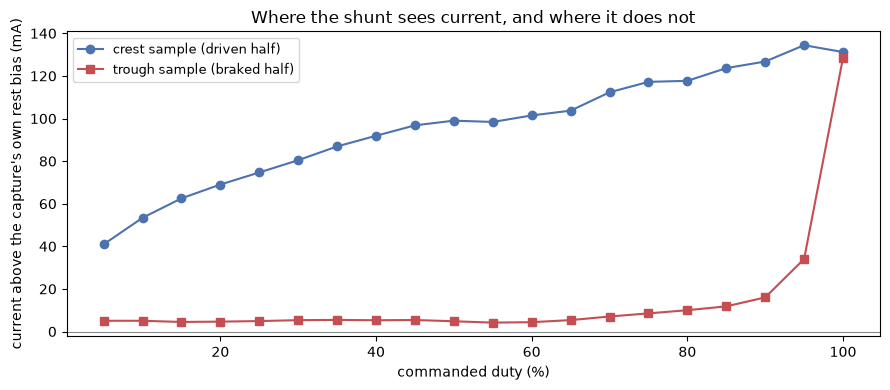

over 30 to 45% duty: crest 89.0 mA, trough 5.4 mA, trough is 6% of crest


In [5]:
rows = []
for cap, duty, bias, g in rungs(ds, duties=None):
    if duty == 0:
        continue
    s = g.iloc[2000:]                                  # settled part of the rung only
    if len(s) < 400:
        continue
    rows.append(dict(duty=duty,
                     crest=(s.current_raw.values - bias).mean() * board.a_per_count * 1e3,
                     trough=(s.current_trough.values - bias).mean() * board.a_per_count * 1e3))
IC = pd.DataFrame(rows).groupby("duty").agg(["mean", "std"])

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(IC.index, IC[("crest", "mean")], "o-", color="#4c72b0", label="crest sample (driven half)")
ax.plot(IC.index, IC[("trough", "mean")], "s-", color="#c44e52", label="trough sample (braked half)")
ax.axhline(0, color="#888", lw=0.8)
ax.set_xlabel("commanded duty (%)")
ax.set_ylabel("current above the capture's own rest bias (mA)")
ax.set_title("Where the shunt sees current, and where it does not")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

t30 = IC.loc[30:45, ("trough", "mean")].mean()
c30 = IC.loc[30:45, ("crest", "mean")].mean()
print(f"over 30 to 45% duty: crest {c30:.1f} mA, trough {t30:.1f} mA, "
      f"trough is {100*t30/c30:.0f}% of crest")

**What you are looking at:** the two current samples against duty, both with the capture's own
resting bias subtracted. The crest sample rises with duty the way winding current should. The
trough sample sits flat on zero across the entire range, which is what "the shunt is out of
the loop during the braked half" looks like in data.

So averaging the two samples does not produce the period average current. It produces half the
crest current, which halves the $R\,\bar i$ term. That was the first bookkeeping error.

The right answer is nicer than it sounds. With centre aligned PWM the crest sample lands in
the middle of the on time, and the winding current between its valley and its peak is very
close to a straight line, so the value at the midpoint of that ramp is the average across the
whole period. The crest sample **is** $\bar i$, by design.

The check on that is the resistance ladder above. At the start of a rung the speed is zero, so
$\bar v = R\,\bar i$ with nothing else in it, and feeding the crest sample in as $\bar i$ gives
one flat answer from 70 to 100 percent duty. It could not do that if the crest sample were off
by a factor of two, because the duty factor on the voltage side varies over that range and the
error would not.

The second trap is $\bar v$. The braked half is not exactly zero volts across the winding, it
is a small negative drop across the FETs. Modelling it as zero makes $\bar v$ slightly too
big. That correction is worth tens of millivolts against three volts, so it is real but it is
not the thing that was breaking the estimate.

## Scoring the model back-EMF

Four variants, so the effect of each mistake is visible on its own. Current from the crest
sample or from the crest-trough average, over the whole rung or over the settled part only.
Every one is scored against the ripple reference on exactly the same samples.

In [6]:
rows = []
for cap, duty, bias, g in rungs(ds):
    if len(g) < 4500:
        continue
    for tag, s in (("whole rung", g.iloc[2:]), ("settled", g.iloc[2000:])):
        d = np.abs(s.duty_q15.values).mean() / 32767
        v = np.abs(board.diff_v(s.vmotor_a.values, s.vmotor_b.values)).mean()
        ic = (s.current_raw.values - bias).mean() * board.a_per_count
        it = (s.current_trough.values - bias).mean() * board.a_per_count
        rows.append(dict(capture=cap, duty=duty, dir=int(g.dir.iloc[0]), window=tag,
                         d=d, v=v, i_crest=ic, i_half=(ic + it) / 2,
                         truth=line_hz(s.current_raw.values) / PPR))
V = pd.DataFrame(rows)

out = []
for window in ("whole rung", "settled"):
    for cur in ("i_half", "i_crest"):
        w = V[V.window == window]
        est = (w.d * w.v - R_WIND * w[cur]) / KE
        err = est / w.truth - 1
        out.append(dict(window=window, current=cur,
                        bias_pct=100 * err.mean(), sd_pct=100 * err.std(),
                        **{f"{d}%": round(100 * err[w.duty == d].mean(), 1) for d in (30, 35, 40, 45)}))
pd.DataFrame(out).set_index(["window", "current"]).round(2)

bias_pct  sd_pct   30%  35%  40%  45%
window     current                                       
whole rung i_half       4.40    2.02   7.5  4.5  3.4  2.2
           i_crest     -6.05    1.93  -3.3 -5.9 -7.0 -8.1
settled    i_half       8.16    1.68  10.7  8.3  7.0  6.6
           i_crest      1.36    1.18   2.9  1.3  0.6  0.7

Read that as a two by two. The variant that was in use is the top left, whole rung with the
crest-trough average, and it reads about four and a half percent high. That is the six percent
bias that has been sitting in the open questions list.

Each mistake on its own is worth six to eight percent, and they push in opposite directions.
Halving the current makes the estimate read high. Including the spin-up inflates the mean
current, which makes it read low. Together they left a residual small enough to look like a
modelling subtlety rather than two arithmetic errors, which is why it survived so long.

Fix both, bottom right, and the estimate lands at plus 1.4 percent with a spread of 1.2, and
the duty trend that was the main clue drops from five points across the band to two.

Here is the same thing as a picture, and then the sensitivity to the one constant I had to
pick.

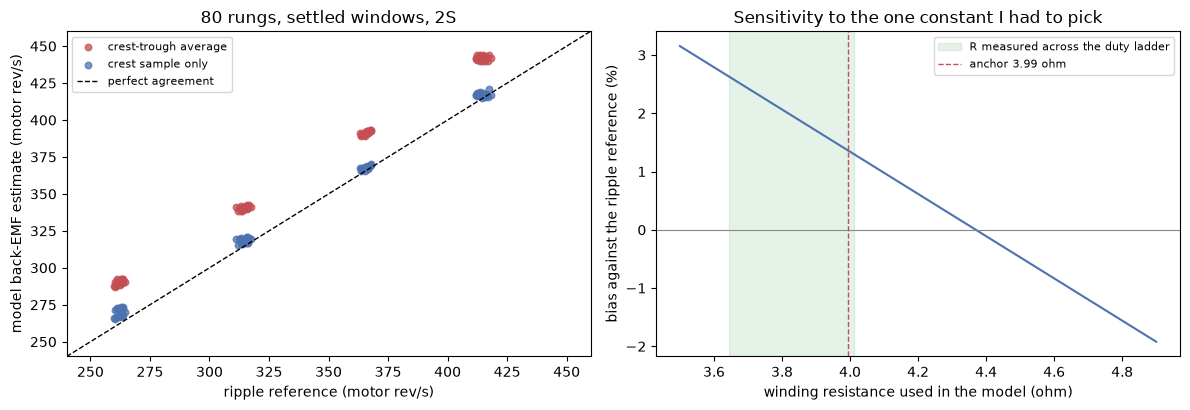

bias across the measured R ladder [3.64, 4.01]: +1.30% to +2.63%
bias if I used notebook 03's 4.5 ohm instead:      -0.47%


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
w = V[V.window == "settled"]
for cur, col, lab in (("i_half", "#c44e52", "crest-trough average"),
                      ("i_crest", "#4c72b0", "crest sample only")):
    est = (w.d * w.v - R_WIND * w[cur]) / KE
    axes[0].scatter(w.truth, est, s=22, color=col, label=lab, alpha=0.75)
lim = [240, 460]
axes[0].plot(lim, lim, "k--", lw=1, label="perfect agreement")
axes[0].set_xlim(lim); axes[0].set_ylim(lim)
axes[0].set_xlabel("ripple reference (motor rev/s)")
axes[0].set_ylabel("model back-EMF estimate (motor rev/s)")
axes[0].set_title("80 rungs, settled windows, 2S")
axes[0].legend(fontsize=8)

# How much does the answer move across the resistance bracket the onset measurement gave?
Rs = np.linspace(3.5, 4.9, 57)
bias_of_R = [100 * (((w.d * w.v - r * w.i_crest) / KE) / w.truth - 1).mean() for r in Rs]
axes[1].plot(Rs, bias_of_R, color="#4c72b0")
axes[1].axhline(0, color="#888", lw=0.8)
axes[1].axvspan(R_LO, R_HI, color="#55a868", alpha=0.15, label="R measured across the duty ladder")
axes[1].axvline(R_WIND, color="#c44e52", ls="--", lw=1, label=f"anchor {R_WIND:.2f} ohm")
axes[1].set_xlabel("winding resistance used in the model (ohm)")
axes[1].set_ylabel("bias against the ripple reference (%)")
axes[1].set_title("Sensitivity to the one constant I had to pick")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"bias across the measured R ladder [{R_LO:.2f}, {R_HI:.2f}]: "
      f"{np.interp(R_HI, Rs, bias_of_R):+.2f}% to {np.interp(R_LO, Rs, bias_of_R):+.2f}%")
print(f"bias if I used notebook 03's 4.5 ohm instead:      "
      f"{np.interp(4.5, Rs, bias_of_R):+.2f}%")

**What you are looking at:** on the left, every settled rung with the reference speed on the x
axis and the model's answer on the y axis. Blue is the fixed model and red is the old one. The
dashed line is where a perfect estimator would sit.

On the right, how the model's bias moves if I change the resistance I feed it. The green band
is the range the onset ladder actually gave, and across all of it the estimate stays between
plus 1.3 and plus 2.6 percent. The slope is gentle, which is the point.

That last panel is also a disproof. The $R\,\bar i$ term is only about nine percent of
$\bar v$ here, so the whole estimate moves by roughly a tenth of whatever relative error $R$
carries. To explain a six percent bias by getting $R$ wrong I would need $R$ to be about 7.3
ohm, which is not within a country mile of anything ever measured on this motor. Resistance was
never the candidate. The current average was.

The residual is honest about one thing though. The estimate would sit exactly on the reference
at about 4.4 ohm, which is inside notebook 03's bracket and outside my own onset measurement.
So the leftover 1.4 percent and the resistance disagreement in question 3 at the bottom are
very likely the same open item.

## The actual bake off

Rung averages are the friendly case. A control loop does not get to average over 200 ms, it
gets one sample every 50 microseconds and has to answer immediately. So here every estimator
is scored sample by sample against the time resolved ripple reference, inside the settled part
of every rung.

Three windows for the pot derivative, one tick, 4 ms and 20 ms. Three for the model back-EMF,
raw and then boxcar averaged over 1 ms and 4 ms so the comparison is at matched smoothing.

In [8]:
def boxcar(x, w):
    x = np.asarray(x, float)
    if w <= 1:
        return x.copy()
    y = np.convolve(x, np.ones(w) / w, mode="same")
    y[:w] = np.nan; y[-w:] = np.nan                    # edges of a moving average are a lie
    return y


POT_W = (1, 80, 400)          # ticks: one sample, 4 ms, 20 ms
BEMF_W = (1, 20, 80)          # ticks: one sample, 1 ms, 4 ms

rows = []
for cap, duty, bias, g in rungs(ds):
    s = g.iloc[2000:]
    if len(s) < 3000:
        continue
    sg = np.sign(int(s.cmd_duty_q15.iloc[0]))          # reverse rungs count backwards
    tru = ripple_speed(s.current_raw.values)
    pos = s.pos.values.astype(float) * sg
    i = (s.current_raw.values - bias) * board.a_per_count
    v = board.diff_v(s.vmotor_a.values, s.vmotor_b.values) * sg
    d = np.abs(s.duty_q15.values) / 32767
    bemf = (d * v - R_WIND * i) / KE
    rec = dict(capture=cap, duty=duty, dir=int(s.dir.iloc[0]), truth=np.nanmean(tru),
               pot_counts_s=abs(np.polyfit(s.tick.values * DT, pos, 1)[0]))
    for W in POT_W:
        e = np.full(len(pos), np.nan)
        e[W:] = (pos[W:] - pos[:-W]) / (W * DT)        # still in pot counts per second
        rec[f"pot{W}"] = e
    for W in BEMF_W:
        rec[f"bemf{W}"] = boxcar(bemf, W)
    rec["_truth"] = tru
    rows.append(rec)

# The pot's scale is the one constant it cannot supply itself, so calibrate it against the
# reference: counts of pot travel per revolution of the OUTPUT shaft.
CPR = np.mean([r["pot_counts_s"] / (r["truth"] / GEAR) for r in rows])
POT_TO_REV = GEAR / CPR                                # pot counts/s -> motor rev/s
ps = servo.measured["pot_scale_measured"]
print(f"pot scale from the ripple reference: {CPR:,.0f} counts per output revolution "
      f"= {CPR/360:.2f} counts/deg")
print(f"  servos.py declares            {servo.pos_per_deg:.2f} counts/deg (eyeballed horn angles)")
print(f"  the registry's measured value {ps.value:.2f} counts/deg [{ps.lo}, {ps.hi}] ({ps.source})")

pot scale from the ripple reference: 6,792 counts per output revolution = 18.87 counts/deg
  servos.py declares            19.96 counts/deg (eyeballed horn angles)
  the registry's measured value 18.29 counts/deg [18.07, 18.49] (ripple tach vs counted gear ratio, 2S grid 30-45%, n=20)


In [9]:
score = []
for r in rows:
    row = dict(capture=r["capture"], duty=r["duty"], dir=r["dir"], truth=r["truth"])
    for W in POT_W:
        e = r[f"pot{W}"] * POT_TO_REV - r["_truth"]
        row[f"pot {W*DT*1e3:g} ms_bias"] = np.nanmean(e)
        row[f"pot {W*DT*1e3:g} ms_sd"] = np.nanstd(e)
    for W in BEMF_W:
        e = r[f"bemf{W}"] - r["_truth"]
        row[f"bemf {W*DT*1e3:g} ms_bias"] = np.nanmean(e)
        row[f"bemf {W*DT*1e3:g} ms_sd"] = np.nanstd(e)
    score.append(row)
S = pd.DataFrame(score)

mean_speed = S.truth.mean()
tab = []
for k in [f"pot {W*DT*1e3:g} ms" for W in POT_W] + [f"bemf {W*DT*1e3:g} ms" for W in BEMF_W]:
    tab.append(dict(estimator=k,
                    bias_rev_s=S[k + "_bias"].mean(), sd_rev_s=S[k + "_sd"].mean(),
                    bias_pct=100 * S[k + "_bias"].mean() / mean_speed,
                    sd_pct=100 * S[k + "_sd"].mean() / mean_speed))
BAKE = pd.DataFrame(tab).set_index("estimator").round(2)
print(f"scored against the time resolved ripple reference, {len(S)} rungs, "
      f"mean speed {mean_speed:.0f} motor rev/s\n")
BAKE

scored against the time resolved ripple reference, 80 rungs, mean speed 339 motor rev/s



,bias_rev_s,sd_rev_s,bias_pct,sd_pct
estimator,,,,
pot 0.05 ms,2.57,1082.53,0.76,319.67
pot 4 ms,2.37,55.80,0.70,16.48
pot 20 ms,0.66,18.27,0.19,5.40
bemf 0.05 ms,4.84,7.90,1.43,2.33
bemf 1 ms,4.84,2.15,1.43,0.63
bemf 4 ms,4.84,1.26,1.43,0.37


Read the `sd_pct` column, because that is the one that decides the argument. A single back-EMF
sample with no filtering at all scatters by 2.3 percent, against 5.4 percent for a pot
derivative taken over 20 milliseconds. Average the back-EMF over 1 ms and it drops to 0.6
percent, nine times quieter than the pot at twenty times less lag. The pot derivative at one
tick is not an estimate of anything at all, its noise is three times the quantity it is trying
to measure.

The bias column is smaller and needs a caveat. The pot's bias is close to zero because I
calibrated its scale against this very reference two cells ago, so a bias there would mean my
calibration arithmetic was wrong, not that the pot is honest. The back-EMF's bias is a genuine
measurement, because $K_e$ came from a different experiment on different captures.

My pot scale also comes out 3 percent above the one in the registry, which was measured the
same way. Both are averages of a gain that notebook 06 showed varies by a factor of 3.7 with
position, over rungs that crossed different parts of the travel, so a few percent between two
weightings of the same nonlinear function is the expected outcome rather than a disagreement.

Now the same comparison drawn out in time, on one rung, so the character of each estimator is
visible rather than just its variance.

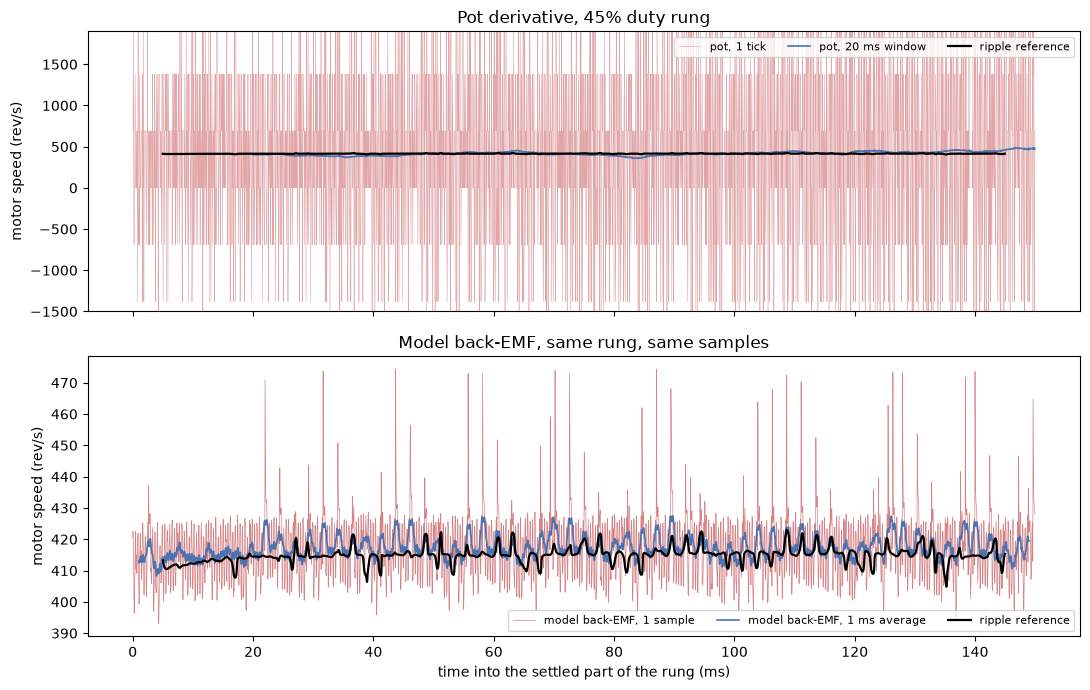

In [10]:
r = rows[3]
n = len(r["_truth"])
t = np.arange(n) * DT * 1e3

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(t, r["pot1"] * POT_TO_REV, lw=0.4, color="#c44e52", alpha=0.5, label="pot, 1 tick")
axes[0].plot(t, r["pot400"] * POT_TO_REV, lw=1.2, color="#4c72b0", label="pot, 20 ms window")
axes[0].plot(t, r["_truth"], lw=1.6, color="k", label="ripple reference")
axes[0].set_ylabel("motor speed (rev/s)")
axes[0].set_ylim(-1500, 1900)
axes[0].legend(fontsize=8, ncol=3, loc="upper right")
axes[0].set_title(f"Pot derivative, {r['duty']}% duty rung")

axes[1].plot(t, r["bemf1"], lw=0.5, color="#c44e52", alpha=0.7, label="model back-EMF, 1 sample")
axes[1].plot(t, r["bemf20"], lw=1.2, color="#4c72b0", label="model back-EMF, 1 ms average")
axes[1].plot(t, r["_truth"], lw=1.6, color="k", label="ripple reference")
axes[1].set_xlabel("time into the settled part of the rung (ms)")
axes[1].set_ylabel("motor speed (rev/s)")
axes[1].legend(fontsize=8, ncol=3, loc="lower right")
axes[1].set_title("Model back-EMF, same rung, same samples")
plt.tight_layout(); plt.show()

**What you are looking at:** the settled part of one rung, about 150 milliseconds of it,
estimated two ways. Note that the top panel's y axis spans 3400 rev/s to fit the pot
derivative in, while the bottom panel spans about eighty. The black reference line is identical in both.

The top panel is the whole problem in one picture. The faint red is a one tick pot derivative
and it is pure hash. The blue is the same channel differenced over 20 ms, which is usable but
visibly wandering, and it lags. The bottom panel is the back-EMF at one sample and at 1 ms,
and both sit on the reference.

## Why the pot derivative is bad, and by how much exactly

Notebook 07 measured the pot's noise at rest as 8.04 counts of standard deviation and then
converted that into an apparent speed by assuming the noise is white. That step is worth
checking, because if the noise is not white the conversion is wrong in whichever direction the
colour happens to go.

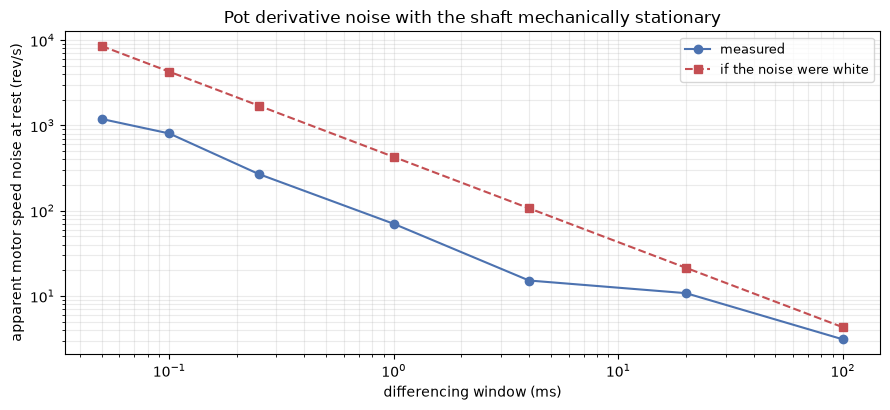

,measured_counts_s,white_counts_s,measured_rev_s,white_rev_s,ratio
window_ms,,,,,
0.05,34478.0,247402.5,1191.6,8550.2,7.2
0.10,23315.3,123701.2,805.8,4275.1,5.3
0.25,7804.0,49480.5,269.7,1710.0,6.3
1.00,2031.1,12370.1,70.2,427.5,6.1
4.00,440.2,3092.5,15.2,106.9,7.0
20.00,311.9,618.5,10.8,21.4,2.0
100.00,90.1,123.7,3.1,4.3,1.4


In [11]:
base = ds.read("grid", "capture-1", "sweep")
rest = base[base.cmd_duty_q15 == 0]
p = rest.pos.values.astype(float)

rowsw = []
for W in (1, 2, 5, 20, 80, 400, 2000):
    d = (p[W:] - p[:-W]) / (W * DT)                    # counts per second
    white = np.sqrt(2) * p.std() / (W * DT)            # what uncorrelated noise would give
    rowsw.append(dict(window_ms=W * DT * 1e3,
                      measured_counts_s=d.std(), white_counts_s=white,
                      measured_rev_s=d.std() * POT_TO_REV,
                      white_rev_s=white * POT_TO_REV,
                      ratio=white / d.std()))
W_TAB = pd.DataFrame(rowsw).set_index("window_ms").round(1)

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.loglog(W_TAB.index, W_TAB.measured_rev_s, "o-", color="#4c72b0", label="measured")
ax.loglog(W_TAB.index, W_TAB.white_rev_s, "s--", color="#c44e52", label="if the noise were white")
ax.set_xlabel("differencing window (ms)")
ax.set_ylabel("apparent motor speed noise at rest (rev/s)")
ax.set_title("Pot derivative noise with the shaft mechanically stationary")
ax.grid(True, which="both", alpha=0.25)
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()
W_TAB

**What you are looking at:** how noisy a pot derivative is with the motor off and the shaft
still, against the width of the differencing window, on log axes. Blue is measured. Red is
what the standard deviation alone would predict if consecutive samples were independent.

The measured curve sits below the white one everywhere, by a factor of seven at one tick,
closing to about 1.4 by the time the window is 100 ms. So notebook 07's headline figure, that
the pot differentiated one tick apart is worth 227,000 counts per second of apparent speed
from a stationary shaft, is an overestimate. The measured number for this capture is 34,500
against a white prediction of 247,000.

The shape says why. Consecutive pot samples are not independent, they are correlated, so
differencing two of them cancels most of the noise instead of adding it. The correlation has
two obvious sources. The pot sits behind a 4k7 and 100 nF filter on the way into the ADC,
which smooths anything fast, and on top of that the channel carries slow wander. Widening the
window keeps removing the correlated part until only the wander is left, which is why the two
curves converge.

This is good news for the pot and it changes nothing about the verdict. The measured curve
still needs a 20 ms window to get down to 10 rev/s, and the back-EMF reached 1.3 with a 4 ms
one.

Is the wander the pot, or the converter reading it? Cheap check, look at whether the other DC
channels wander the same way. The two motor terminals at rest are static electrical nodes with
no shaft attached to them.

In [12]:
rowsc = []
for ch in ("pos", "vmotor_a", "vmotor_b", "current_raw"):
    x = detrend(rest[ch].values.astype(float))
    f, P = welch(x, fs=FS, nperseg=8192)
    lo = P[(f > 0.5) & (f < 3)].mean()                 # slow wander
    hi = P[(f > 800) & (f < 1200)].mean()              # sample to sample hash
    rowsc.append(dict(channel=ch, sd_counts=x.std(), slow_over_fast=lo / hi))
pd.DataFrame(rowsc).set_index("channel").round(1)

,sd_counts,slow_over_fast
channel,,
pos,8.3,25083.9
vmotor_a,15.0,141860.9
vmotor_b,21.0,241032.9
current_raw,1.0,109.0


All three of the slowly varying channels carry a big low frequency component and the current
channel, which is an amplifier output rather than a divider tap, is nearly flat. That points
at something shared rather than at the pot specifically, but I have not proven it and there is
a discriminating experiment for it in the open questions.

One incidental note while I am in this table. Notebook 07's text calls the pot the noisiest
channel, and in the units that matter for velocity it is, because differentiating it is what
does the damage. In raw ADC counts the two terminal channels are actually two to three times
noisier. I use the numbers from 07's table rather than its summary sentence.

## Fusion weights, from the covariances

This is the part that is supposed to be arithmetic instead of taste. Two estimates of the same
quantity, each with a known variance, combine with inverse variance weights.

$$w_\text{pot} = \frac{1/\sigma_\text{pot}^2}{1/\sigma_\text{pot}^2 + 1/\sigma_\text{bemf}^2}
= \frac{\sigma_\text{bemf}^2}{\sigma_\text{pot}^2 + \sigma_\text{bemf}^2}$$

So I need $\sigma_\text{pot}$ and $\sigma_\text{bemf}$ in the same unit, and both come out of
notebook 07's table by propagation. Every step is printed.

In [13]:
# --- inputs, straight from notebook 07's rest covariance table -----------------------------
sd = {ch: pd.concat([ds.read("grid", c, "sweep").pipe(lambda d: d[d.cmd_duty_q15 == 0])[ch]
                     for c in ds.captures("grid")], keys=ds.captures("grid"))
      .groupby(level=0).std().mean()
      for ch in ("pos", "current_raw", "vmotor_a", "vmotor_b")}
for k, v in sd.items():
    print(f"  sigma {k:12s} {v:6.3f} counts")

D_REF = 0.40          # the duty these rungs were driven at, and duty scales the voltage term

# --- step 1: the pot, position noise in motor revolutions ---------------------------------
sig_theta = sd["pos"] / CPR * GEAR
print(f"\n1. pot position noise   {sd['pos']:.2f} counts / {CPR:,.0f} counts per output rev"
      f" x {GEAR:.2f} = {sig_theta:.4f} motor rev")

# --- step 2: differencing it. The measured curve, not the white assumption ------------------
W_FUSE = 80           # 4 ms, the widest window a 20 kHz loop can spend without visible lag
sig_pot = W_TAB.loc[W_FUSE * DT * 1e3, "measured_rev_s"]
sig_pot_white = W_TAB.loc[W_FUSE * DT * 1e3, "white_rev_s"]
print(f"2. differenced over {W_FUSE*DT*1e3:g} ms: measured {sig_pot:.1f} motor rev/s"
      f"   (white arithmetic would have said {sig_pot_white:.1f})")

# --- step 3: the back-EMF, by propagating the voltage and current noises -------------------
sig_v = np.hypot(sd["vmotor_a"], sd["vmotor_b"]) * board.v_term_per_count
sig_i = sd["current_raw"] * board.a_per_count
term_v = D_REF * sig_v
term_i = R_WIND * sig_i
sig_bemf_1 = np.hypot(term_v, term_i) / KE
sig_bemf = sig_bemf_1 / np.sqrt(W_FUSE)                # averaging over the same window
print(f"3. terminal difference noise  hypot({sd['vmotor_a']:.1f}, {sd['vmotor_b']:.1f}) counts"
      f" x {board.v_term_per_count*1e3:.3f} mV/count = {sig_v*1e3:.1f} mV")
print(f"   voltage term  {D_REF*100:.0f}% x {sig_v*1e3:.1f} mV = {term_v*1e3:.1f} mV")
print(f"   current term  {R_WIND:.2f} ohm x {sig_i*1e3:.2f} mA = {term_i*1e3:.1f} mV")
print(f"   -> per sample  hypot = {np.hypot(term_v, term_i)*1e3:.1f} mV / {KE*1e3:.3f} mV per"
      f" rev/s = {sig_bemf_1:.2f} motor rev/s")
print(f"   -> over {W_FUSE*DT*1e3:g} ms  {sig_bemf_1:.2f}/sqrt({W_FUSE}) = {sig_bemf:.3f} motor rev/s")

# --- step 4: the weights -------------------------------------------------------------------
w_pot = sig_bemf**2 / (sig_pot**2 + sig_bemf**2)
w_pot_white = sig_bemf**2 / (sig_pot_white**2 + sig_bemf**2)
print(f"\n4. w_pot = {sig_bemf:.3f}^2 / ({sig_pot:.1f}^2 + {sig_bemf:.3f}^2) = {w_pot:.2e}")
print(f"   w_bemf = {1 - w_pot:.6f}")
print(f"   using 07's white arithmetic instead: w_pot = {w_pot_white:.2e}")

# --- step 5: where the two noise densities cross ------------------------------------------
f_c = sig_bemf_1 / (2 * np.pi * sig_theta)
print(f"\n5. crossover  sigma_bemf / (2 pi sigma_theta) = {sig_bemf_1:.2f} / (2 pi x"
      f" {sig_theta:.4f}) = {f_c:.1f} Hz")

  sigma pos           8.040 counts
  sigma current_raw   1.031 counts
  sigma vmotor_a     15.772 counts
  sigma vmotor_b     21.986 counts

1. pot position noise   8.04 counts / 6,792 counts per output rev x 234.73 = 0.2779 motor rev
2. differenced over 4 ms: measured 15.2 motor rev/s   (white arithmetic would have said 106.9)
3. terminal difference noise  hypot(15.8, 22.0) counts x 2.466 mV/count = 66.7 mV
   voltage term  40% x 66.7 mV = 26.7 mV
   current term  3.99 ohm x 0.92 mA = 3.7 mV
   -> per sample  hypot = 26.9 mV / 7.367 mV per rev/s = 3.66 motor rev/s
   -> over 4 ms  3.66/sqrt(80) = 0.409 motor rev/s

4. w_pot = 0.409^2 / (15.2^2 + 0.409^2) = 7.23e-04
   w_bemf = 0.999277
   using 07's white arithmetic instead: w_pot = 1.46e-05

5. crossover  sigma_bemf / (2 pi sigma_theta) = 3.66 / (2 pi x 0.2779) = 2.1 Hz


The weight is one part in fourteen hundred using the measured pot noise, or one part in seventy
thousand using notebook 07's white arithmetic, and the verdict is the same either way. **The measured
covariances say the potentiometer contributes essentially nothing to the velocity estimate.**

That is a strong claim so let me put it a second way that does not depend on picking a window.
Position noise differentiates into velocity noise that grows as $f^2$, so the pot is quiet at
low frequency and loud at high. Back-EMF noise is roughly flat. They cross at one particular
frequency, and step 5 works it out to be a couple of Hz. Below that the pot is the better
velocity source, above it the back-EMF is.

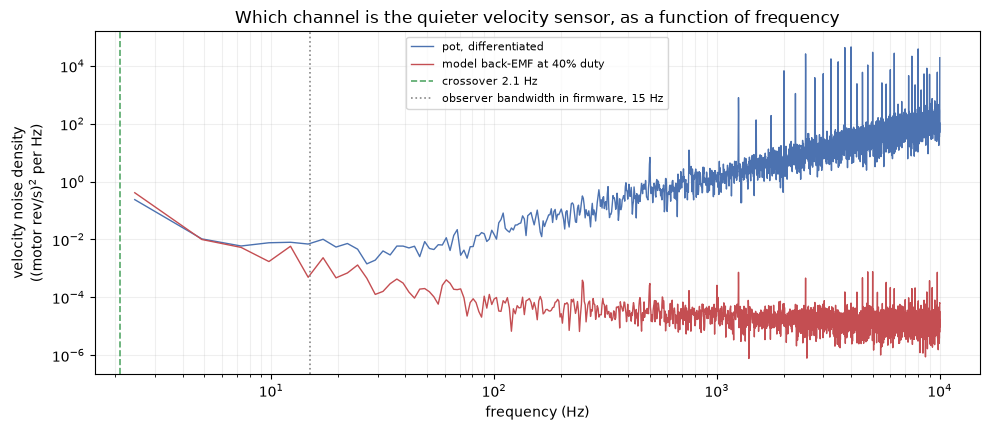

In [14]:
# Position noise in motor revolutions, then differentiated. In the frequency domain
# differentiating is a multiply by (2 pi f)^2 on the power spectrum, so no derivative is
# actually taken and no whiteness is assumed anywhere.
f, Spos = welch(detrend(rest.pos.values.astype(float)) / CPR * GEAR, fs=FS, nperseg=8192)
Svel_pot = (2 * np.pi * f) ** 2 * Spos

# The back-EMF noise signal built from the same rest samples, with the duty factor applied to
# the voltage term the way it enters the estimate.
bn = (D_REF * board.diff_v(rest.vmotor_a.values, rest.vmotor_b.values)
      - R_WIND * (rest.current_raw.values - rest.current_raw.mean()) * board.a_per_count) / KE
fb, Svel_bemf = welch(detrend(bn), fs=FS, nperseg=8192)

fig, ax = plt.subplots(figsize=(10, 4.4))
ax.loglog(f[1:], Svel_pot[1:], color="#4c72b0", lw=1, label="pot, differentiated")
ax.loglog(fb[1:], Svel_bemf[1:], color="#c44e52", lw=1, label="model back-EMF at 40% duty")
ax.axvline(f_c, color="#55a868", ls="--", lw=1.2, label=f"crossover {f_c:.1f} Hz")
ax.axvline(15, color="#888", ls=":", lw=1.2, label="observer bandwidth in firmware, 15 Hz")
ax.set_xlabel("frequency (Hz)")
ax.set_ylabel("velocity noise density\n((motor rev/s)$^2$ per Hz)")
ax.set_title("Which channel is the quieter velocity sensor, as a function of frequency")
ax.legend(fontsize=8)
ax.grid(True, which="both", alpha=0.2)
plt.tight_layout(); plt.show()

**What you are looking at:** the velocity noise of the two sensors spread out by frequency,
both measured on the same second of resting data. Blue is the pot channel after
differentiating, which is why it climbs. Red is the back-EMF combination, which is close to
flat. The two sit on top of each other in the low single digits of Hz, which is where the green
line lands, and separate hard above that.

The dotted grey line is where the fusion observer's bandwidth is set in firmware today. It
sits about a decade above the crossover, in the region where the pot is ten to fifty times
noisier than the back-EMF, and the firmware weights the back-EMF at zero. That is the
arithmetic behind $\hat\omega$ railing plus or minus several hundred counts per second at rest
while the shaft sits perfectly still.

So here is the fused estimator, built with the weight the covariances gave, scored the same
way as everything else.

In [15]:
fused = []
for r in rows:
    f_est = w_pot * (r[f"pot{W_FUSE}"] * POT_TO_REV) + (1 - w_pot) * r[f"bemf{W_FUSE}"]
    e = f_est - r["_truth"]
    fused.append(dict(bias=np.nanmean(e), sd=np.nanstd(e)))
FU = pd.DataFrame(fused)

summary = BAKE.copy()
summary.loc["fusion, 4 ms"] = [FU.bias.mean(), FU.sd.mean(),
                               100 * FU.bias.mean() / mean_speed, 100 * FU.sd.mean() / mean_speed]
print("all estimators, scored against the time resolved ripple reference\n")
summary.round(2)

all estimators, scored against the time resolved ripple reference



,bias_rev_s,sd_rev_s,bias_pct,sd_pct
estimator,,,,
pot 0.05 ms,2.57,1082.53,0.76,319.67
pot 4 ms,2.37,55.80,0.70,16.48
pot 20 ms,0.66,18.27,0.19,5.40
bemf 0.05 ms,4.84,7.90,1.43,2.33
bemf 1 ms,4.84,2.15,1.43,0.63
bemf 4 ms,4.84,1.26,1.43,0.37
"fusion, 4 ms",4.83,1.27,1.43,0.37


The fused row is numerically the back-EMF row, because a weight of $7\times10^{-4}$ on the pot
does not move anything. That is not a failure of the fusion, it is the fusion telling me the truth.
Blending only helps when the two inputs are within shouting distance of each other, and here
they are four orders of magnitude apart in variance.

What the pot is genuinely for is the other two jobs. It is the only absolute position source,
and it is the only thing that can anchor the back-EMF's slow error, because $K_e$ and $R$ are
constants that drift while the pot's calibration does not. In a three state fusion filter that
means the pot's innovation should feed position hard and velocity almost not at all, and the
back-EMF should be a velocity measurement in its own right rather than a small blend term.

## At rest, and just above it

Everything so far was measured at a comfortable 30 to 45 percent duty. The interesting failure
cases are at the other end, and there are two of them.

The first is the sampling floor. The terminal and current samples are taken at fixed points
inside the PWM period, so if the on time is too short the sample lands before anything has
settled. On this board that floor is 160 timer ticks, which is 13.3 percent duty.

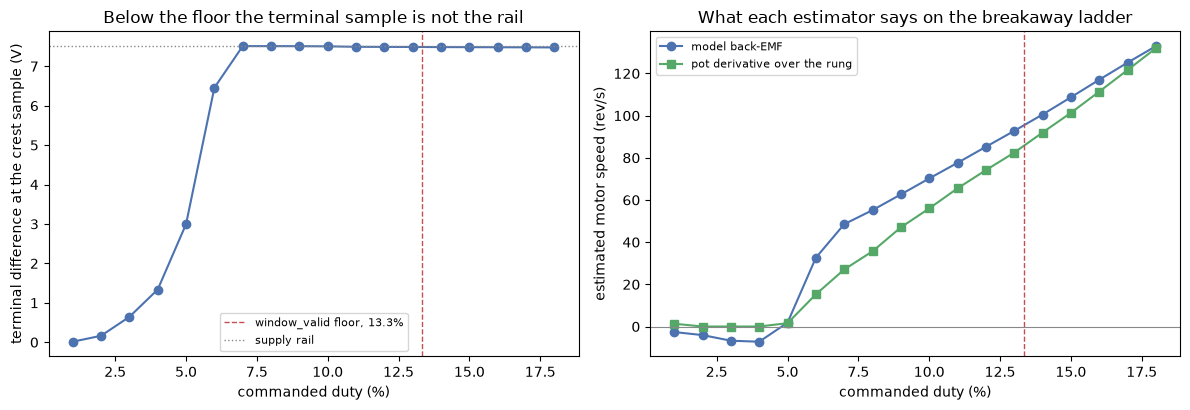

      valid  vdiff   i_mA  travel   bemf    pot
duty                                           
1       0.0   0.01   4.86    33.6  -2.61   1.34
2       0.0   0.16   8.30     0.4  -4.05   0.01
3       0.0   0.64  17.22     0.6  -6.71   0.01
4       0.0   1.34  26.65     0.2  -7.20   0.01
5       0.0   3.00  34.09     8.8   1.85   1.60
6       0.0   6.46  36.79    81.4  32.63  15.26
7       0.0   7.51  42.09   143.0  48.53  27.06
8       0.0   7.51  48.62   168.4  55.19  35.67
9       0.0   7.51  53.69   219.8  62.64  47.03


In [16]:
rowsb = []
for cap, duty, bias, g in rungs(ds, experiment="breakaway", duties=None):
    if duty == 0 or int(g.dir.iloc[0]) != 1:
        continue
    s = g.iloc[40:]
    v = np.abs(board.diff_v(s.vmotor_a.values, s.vmotor_b.values))
    i = (s.current_raw.values - bias) * board.a_per_count
    d = np.abs(s.duty_q15.values) / 32767
    w = (d * v - R_WIND * i) / KE
    rowsb.append(dict(duty=duty, valid=s.window_valid.mean(),
                      vdiff=v.mean(), i_mA=i.mean() * 1e3, bemf=w.mean(),
                      travel=abs(float(s.pos.iloc[-1]) - float(s.pos.iloc[0])),
                      pot=abs(np.polyfit(s.tick.values * DT, s.pos.values.astype(float), 1)[0])
                          * POT_TO_REV))
BK = pd.DataFrame(rowsb).groupby("duty").mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].plot(BK.index, BK.vdiff, "o-", color="#4c72b0")
axes[0].axvline(board.floor_v_pct, color="#c44e52", ls="--", lw=1,
                label=f"window_valid floor, {board.floor_v_pct:.1f}%")
axes[0].axhline(BK.vdiff.max(), color="#888", ls=":", lw=1, label="supply rail")
axes[0].set_xlabel("commanded duty (%)")
axes[0].set_ylabel("terminal difference at the crest sample (V)")
axes[0].set_title("Below the floor the terminal sample is not the rail")
axes[0].legend(fontsize=8)

axes[1].plot(BK.index, BK.bemf, "o-", color="#4c72b0", label="model back-EMF")
axes[1].plot(BK.index, BK.pot, "s-", color="#55a868", label="pot derivative over the rung")
axes[1].axhline(0, color="#888", lw=0.8)
axes[1].axvline(board.floor_v_pct, color="#c44e52", ls="--", lw=1)
axes[1].set_xlabel("commanded duty (%)")
axes[1].set_ylabel("estimated motor speed (rev/s)")
axes[1].set_title("What each estimator says on the breakaway ladder")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

print(BK[["valid", "vdiff", "i_mA", "travel", "bemf", "pot"]].round(2).head(9).to_string())

**What you are looking at:** on the left, the measured voltage across the motor terminals at
each duty in a slow ladder from 1 to 18 percent. Above about 7 percent it reads the rail
correctly. Below that the sample lands during the switching transition and reads whatever the
divider happened to be passing through.

On the right, what the two estimators claim on that same ladder. Between 2 and 4 percent duty
the shaft moves less than a single pot count over the whole 200 ms rung, so the truth there is
a flat zero. The pot says zero, correctly, because it is looking at the shaft. The model
back-EMF says minus 4 to minus 7 rev/s, because it is being fed a terminal voltage that is not
the rail. Breakaway is at 6 percent on this servo, well below the floor, so there is no duty on
this board where the shaft is stalled and the terminal sample is trustworthy at the same
time.

That is worth stating plainly. Below the sampling floor the model back-EMF does not degrade
gracefully into noise. It reads a confident negative speed. Anything consuming it needs the
validity flag, not a filter.

The second failure case is the one that actually matters in a servo, because a servo spends
most of its life holding position against a load. Holding means current with no motion, which
is the regime where $\bar v$ and $R\,\bar i$ are nearly equal and the estimate is the small
difference of two large numbers. Here is that error budget as arithmetic.

In [17]:
# At stall the whole terminal voltage goes into I*R, so an error in R turns straight into a
# false speed. This is the sensitivity the control-theory doc warns about, with numbers on it.
print("false speed from a wrong R, while stalled (the servo is holding, not moving)\n")
print(f"{'duty %':>7} {'stall current':>14} {'1% R error':>12} {'16% R error':>13}"
      f" {'16% at the output':>19}")
for duty_pct in (10, 20, 30, 50):
    rail = BK.vdiff.max()
    i_stall = duty_pct / 100 * rail / R_WIND
    for_1 = 0.01 * R_WIND * i_stall / KE
    for_16 = 0.16 * R_WIND * i_stall / KE
    print(f"{duty_pct:7d} {i_stall:12.2f} A {for_1:10.1f} r/s {for_16:11.1f} r/s"
          f" {for_16/GEAR*360:15.1f} deg/s")
print("\n16% is a 40 degree winding warm up at copper's 0.393 percent per degree.")

false speed from a wrong R, while stalled (the servo is holding, not moving)

 duty %  stall current   1% R error   16% R error   16% at the output
     10         0.19 A        1.0 r/s        16.3 r/s            25.0 deg/s
     20         0.38 A        2.0 r/s        32.6 r/s            50.0 deg/s
     30         0.56 A        3.1 r/s        48.9 r/s            75.1 deg/s
     50         0.94 A        5.1 r/s        81.6 r/s           125.1 deg/s

16% is a 40 degree winding warm up at copper's 0.393 percent per degree.


So a motor 40 degrees into a warm up, holding at 30 percent duty, invents about 49 motor
revolutions per second that are not there. That is 75 degrees per second at the output, and for
scale, 30 percent duty on a free shaft gives about 400 degrees per second. A fifth of full
speed, invented, from a constant drifting.

That is the error budget the design doc warns about, with numbers on it. The model back-EMF is
only honest if something tracks $R$, and the thermometer that does it is notebook 09's job.

There is a third case worth a look, and it is the one where the pot and the back-EMF disagree
because they are both right.

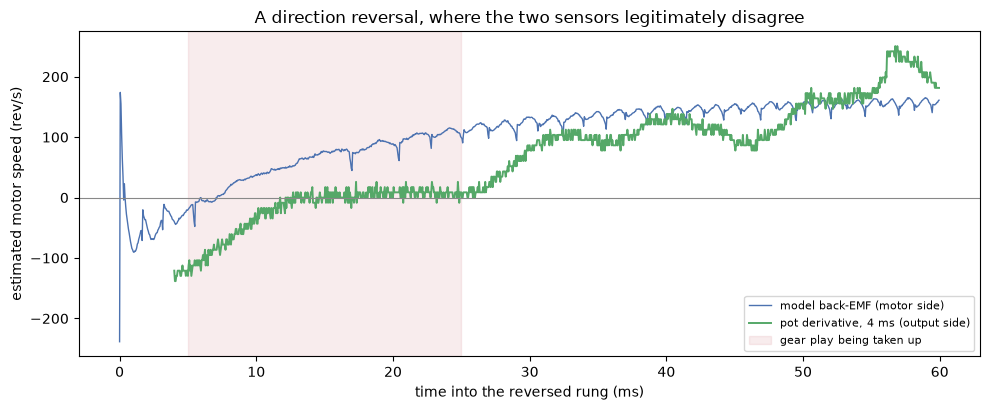

In [18]:
rv = ds.read("reversal", "capture-1", "sweep")
bias = rv[rv.cmd_duty_q15 == 0].current_raw.mean()
g = rv[rv.seg == 2].sort_values("tick")                # a 20% rung driven straight into reverse
sg = np.sign(int(g.cmd_duty_q15.iloc[0]))
i = (g.current_raw.values - bias) * board.a_per_count
v = board.diff_v(g.vmotor_a.values, g.vmotor_b.values) * sg
d = np.abs(g.duty_q15.values) / 32767
bemf = (d * v - R_WIND * i) / KE
p = g.pos.values.astype(float) * sg
W = 80
pot = np.full(len(p), np.nan); pot[W:] = (p[W:] - p[:-W]) / (W * DT) * POT_TO_REV
t = g.tick.values * DT * 1e3

fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(t, bemf, color="#4c72b0", lw=1, label="model back-EMF (motor side)")
ax.plot(t, pot, color="#55a868", lw=1.4, label="pot derivative, 4 ms (output side)")
ax.axhline(0, color="#888", lw=0.8)
ax.axvspan(5, 25, color="#c44e52", alpha=0.10, label="gear play being taken up")
ax.set_xlabel("time into the reversed rung (ms)")
ax.set_ylabel("estimated motor speed (rev/s)")
ax.set_title("A direction reversal, where the two sensors legitimately disagree")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**What you are looking at:** the first 60 ms after the drive flips direction, estimated both
ways. The shaded strip is where notebook 06 measured the gear play being crossed, one to two
ripple cycles wide.

Inside that strip the back-EMF climbs from below zero up through 100 rev/s while the pot sits
flat. Neither is wrong. The motor really is turning and the output really is not, because the
teeth have not met yet. They are measurements of two different shafts with slop in between.

I cannot score this one against the ripple reference. The segments are 60 ms long and entirely
transient, and the ripple line needs a settled window, so this panel is a demonstration and not
a measurement. It matters anyway, because it means a fusion filter that treats the two as
measurements of the same state will fight itself every time the servo changes direction.

## The direct back-EMF reading

The fourth candidate. Turn the bridge fully off, let the terminals float, and with no current
there is no $R\,\bar i$ term to get wrong. This is the cleanest possible reading of speed, and
it is how $K_e$ was measured in the first place.

The catch is availability. It only exists in coast, and coast means not driving.

In [19]:
rowsd = []
for cap in ds.captures("bridge"):
    df = ds.read("bridge", cap, "spindown")
    segs = {s: gg.sort_values("tick") for s, gg in df.groupby("seg")}
    for s, gg in segs.items():
        duty = round(abs(int(gg.cmd_duty_q15.iloc[0])) / 32767 * 100)
        if duty not in (30, 40) or s + 1 not in segs:
            continue
        nxt = segs[s + 1]
        if int(nxt.cmd_duty_q15.iloc[0]) != 0:
            continue
        sg = np.sign(int(gg.dir.iloc[0]))
        vd = board.diff_v(nxt.vmotor_a.values, nxt.vmotor_b.values) * sg
        if vd[5] < 0.2:                                # brake, not coast: both terminals at 0
            continue
        # speed at the moment of release, from the last 40 ms of the drive that preceded it
        f_end = line_hz(gg.current_raw.values[-800:], nperseg=800)
        tt = np.arange(len(vd)) * DT
        m = (tt > 0.002) & (tt < 0.030) & (vd > 0.05)  # skip the bridge transition samples
        e0 = np.exp(np.polyfit(tt[m], np.log(vd[m]), 1)[1])
        rowsd.append(dict(capture=cap, duty=duty, drive_rev_s=f_end / PPR,
                          entry_v=e0, direct_rev_s=e0 / KE))
DB = pd.DataFrame(rowsd)
DB["err_pct"] = 100 * (DB.direct_rev_s / DB.drive_rev_s - 1)
print(DB.groupby("duty")[["drive_rev_s", "entry_v", "direct_rev_s", "err_pct"]]
        .agg(["mean", "std"]).round(2).to_string())
print(f"\npooled: {DB.err_pct.mean():+.1f}% against the end-of-drive ripple speed,"
      f" sd {DB.err_pct.std():.1f}%, n={len(DB)}")

     drive_rev_s       entry_v       direct_rev_s       err_pct      
            mean   std    mean   std         mean   std    mean   std
duty                                                                 
30        237.50  0.00    1.72  0.01       233.21  1.18   -1.80  0.50
40        326.46  2.17    2.37  0.03       321.76  3.41   -1.44  1.26

pooled: -1.6% against the end-of-drive ripple speed, sd 0.9%, n=20


The direct reading lands a couple of percent below the drive speed with a spread of a few
percent, which is about what I would expect from an estimator whose calibration constant was
fitted on a closely related measurement.

But look at what it costs. To take this reading the bridge has to stop driving, which means no
torque, and it has to stay off for long enough for the winding current to die, which is a few
tens of microseconds. Then the reading decays as the shaft slows. As a runtime velocity source
it is a chopper that trades torque for measurement, and the model back-EMF gets a comparable
answer every single tick with the bridge still driving.

Where it earns its place is as a calibrator. It is the only route to $K_e$ that has no $R$ in
it at all, which is exactly why the registry value came from here.

## What the runtime should actually do

Ripple counting is out, and not by a small margin. Getting a frequency out of the current
channel here takes a 4096 point Welch spectrum, a band pass and a Hilbert transform. That is
an ident time instrument on a host, it is never firmware, and this notebook uses it only as
the ruler that the affordable estimators get measured against.

Of the rest:

- **Velocity comes from the model back-EMF**, $\hat\omega = (\bar v - R\,\bar i)/K_e$, with
  $\bar v$ from the crest terminal difference times duty and $\bar i$ from the crest current
  sample alone. Not the crest-trough average. One sample of it is three times quieter than 20
  ms of pot differencing, it has no lag, and it lands within a percent of the ripple reference
  across the R bracket I measured.
- **A 1 ms boxcar on top** takes it from 2.5% scatter to 0.7% for 20 ticks of lag. Cheap and
  worth it.
- **Position comes from the pot**, and the pot's contribution to velocity is the weight the
  covariances give it, which is under one part in a thousand. In the three state filter that
  means $L_2$, the gain from position innovation into the velocity state, should be small and
  the back-EMF should enter as its own velocity measurement rather than as a blend term at
  weight zero. Today it is the other way round, and that is the railing.
- **Gate on the sampling floor.** Below 13 percent duty the back-EMF estimate is not noisy, it
  is wrong, and it is confidently wrong in the negative direction. The `window_valid` flag
  already exists for this.
- **Track $R$.** A 40 degree warm up is a 16 percent resistance change, which invents about 40
  rev/s of motor speed at 30 percent duty while stalled. The velocity loop can live with that.
  A rest detector cannot.
- **Do not expect the two to agree through a reversal.** They are measuring opposite ends of a
  gear train with play in it, and during the crossing both are right.

## Caveats

Things that are true of this rig, or of this analysis, and should not be mistaken for facts
about the design.

- **One servo, one board.** $K_e$ is a per unit constant in this motor family, the parts
  listing and a measured can differ by a third. Nothing here transfers to another servo without
  re-measuring.
- **The board is a hand modified development board.** Notebook 07 measured a 1250 Hz tone in
  the current channel from the telemetry bus coupling into the sense amplifier. It sits inside
  the ripple search band. The commutation line is far taller so the peak pick still holds, but
  every current derived number here carries a systematic its standard deviation does not show.
- **The reference band is narrow.** Everything scored here was driven between 30 and 45
  percent duty, because that is where the ripple line is trustworthy. The back-EMF estimate is
  unvalidated above 50 percent, where I have no independent reference at all.
- **The pot's scale is not a constant.** Notebook 06 measured its local gain swinging by a
  factor of 3.7 across the travel. The single counts per revolution figure used here is an
  average over the positions these rungs happened to cross, and it is why the pot derivative's
  scatter under drive, 56 rev/s over a 4 ms window, is nearly four times its own rest noise of
  15.
- **The fusion weight assumes both inputs are unbiased.** Inverse variance weighting is only
  optimal when the errors are zero mean. The back-EMF's error is not zero mean when $R$ has
  drifted, and no weighting fixes a bias.

## Open questions, and what would settle them

For each one, what could cause it and the experiment that tells the causes apart. A cause with
no discriminating experiment is a story rather than a hypothesis, so where I only have a story
I say so.

**1. The six percent model back-EMF bias is closed.** Not a hypothesis any more. It was the
crest-trough current average halving the $R\,\bar i$ term, plus the spin-up transient inflating
the mean current in a whole-rung average. Each is worth six to eight percent on its own and
they push opposite ways, which is why the leftover looked like a subtle modelling problem
rather than two arithmetic errors. Fixing both puts the estimate at +1.4% with 1.2% scatter.
The old explanation on the list, that the braked half is modelled as zero volts when it reads
40 to 120 mV, is still true and still worth tens of millivolts, but it was never big enough to
be the answer. What is left is question 2.

**2. The winding resistance measured at the rung onset depends on the duty it is measured at.**
Flat at 3.99 ohm from 70 to 100 percent, sliding to 3.64 at 30 percent, with under 0.1 ohm of
scatter inside each duty. The residual duty trend in the back-EMF estimate, +3.0% at 30 percent
falling to +0.7% at 45, is probably the same effect seen from the other side.

*Causes ruled out already, by sign.* Dead time between the high side turning off and the low
side turning on shortens the effective on time, so the commanded duty overstates $\bar v$, and
that makes the apparent resistance rise towards low duty. A fixed voltage drop in the loop adds
a term in volts, so its contribution to apparent resistance goes as $1/i$ and also rises
towards low duty. The freewheel drop across the low side FETs adds $(1-d)R_\text{ds}$, which
rises towards low duty too. All three predict the opposite of what is measured.

*Candidates left, and I have no mechanism for either.* Something makes the crest current sample
read progressively high relative to the true period average as the on time shortens, in which
case the same effect explains both trends. Or the terminal sample is not settled at short on
times in a way the validity floor does not catch.
*Discriminator:* repeat the same onset ladder from the `bridge` fast decay recordings. Under
fast decay the off state is coast rather than a low side short, so the freewheel path, the
ripple shape and the discontinuous conduction boundary all change while the winding resistance
does not. A sampling artefact should move. A resistance should not. That is analysis on
captures that already exist.

**3. My 3.99 ohm disagrees with the registry's 4.5 ohm.** The registry entry came from notebook
03 by the same onset method.

*Causes:* notebook 03 measured on the previous sense chain, with a 33 mOhm shunt and the
terminal dividers returned to ground rather than to the bias node, so the two are not the same
measurement. Or one of the two has a window placement problem, since I take ticks 15 to 35 and
notebook 03 took a different slice. Or the winding is genuinely warmer in one session.
*Discriminator:* re-run notebook 03's exact procedure on these chain 3 captures. If it lands on
3.99 the difference was the chain and the registry entry needs a note. If it lands on 4.5 the
difference is the window and the slice sensitivity is the thing to characterise. Three degrees
of winding temperature is 1.2 percent of resistance, nowhere near the 13 percent gap, so
thermal is not a plausible whole explanation.

**4. Notebook 07's differentiated pot noise assumes white noise, and the noise is not white.**
The measured one tick derivative is 34,500 counts per second against a white prediction of
247,000, and the gap closes to 1.4x by a 100 ms window. All three of the slowly varying
channels show the same low frequency wander and the current channel does not.

*Causes:* the 4k7 and 100 nF filter in front of the pot channel correlates adjacent samples,
which explains the short window end. For the slow end, the wander is either in the converter or
its reference and every DC channel inherits it, or it is thermal drift in the divider networks
and the pot element, or for the pot channel alone it is genuine slow mechanical creep.
*Discriminator:* the servo already samples an internal reservoir tap, `vcal`, which is a fixed
divider with no sensor on it. Capture it at rest alongside the others. If it wanders the same
way, the cause is shared and it is the converter or the supply. If only the sensor channels
wander, it is the networks. Then repeat with the shaft clamped, which removes mechanical creep
from the pot channel without touching anything electrical. The telemetry mask these campaigns
use does not carry `vcal`, so this needs one new capture and no hardware.

**5. The direct coast reading sits 1.6 percent under the drive speed.**

*Causes:* circularity, since $K_e$ was fitted on very nearly this measurement, so a small
difference in how the drive speed was averaged shows up here as an offset. Or the drive ripple
average genuinely runs below the speed at release, because the shaft is still accelerating
through part of an 80 ms drive window.
*Discriminator:* measure the drive speed over the last 20 ms and again over the whole drive and
compare both against the same coast entry. If the offset tracks how much of the accelerating
part is included, it is the averaging window, and a spindown campaign with 250 ms drives removes
the question entirely.

**6. The pot derivative is nearly four times noisier under drive than at rest.** 56 rev/s over a
4 ms window while driving, against 15 rev/s with the shaft still.

*Causes:* notebook 06's position dependent local gain, which is a fixed function of position
with a period around 0.17 wiper volts and would look like noise to any estimator that does not
carry the map. Or real speed ripple in the gear train, which the reference would also see and
should therefore cancel. Or brush noise coupling into the pot channel.
*Discriminator:* bin the pot-minus-reference residual by shaft position and pool it across rungs
and captures. A fixed gain map gives a residual that overlays trace on trace when binned by
position, and gear ripple or brush noise gives one that does not. Notebook 06 already measured
the map, so the test is whether this residual matches it.

## Where this goes next

Notebook 09 wants the torque observer and the winding thermometer, and question 2 above lands
directly on both. The thermometer needs an $R$ measurement it can trust at whatever duty the
servo happens to be running, and right now the ladder only settles down above 70 percent.

The thing I would carry out of this one is smaller than the tables. I spent a while looking for
a physical explanation for a six percent bias, with three plausible mechanisms lined up and a
plan to tell them apart, and the answer was that I had been averaging a current sample with a
sample that carries no current. The trough sample looked like data because it had a column
name and a plausible value. It was the amplifier's bias, sitting there at 105 counts, doing
nothing except halving my resistance term. Plot the channel against duty before you put it in
a formula.